In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycirclize import Circos

# where to save figures
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/chord_diagram_demo")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Ready. pycirclize version check:", Circos.__module__)


Ready. pycirclize version check: pycirclize.circos


In [3]:
# --- INPUTS you can tweak ---
CSV_IN   = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/master_df_interactions_all.csv")
SELECT_COND  = None      # e.g., "RTCyPSCA" or keep None to pool
SELECT_MOUSE = None      # e.g., "RTCyPSCA_2_4" or keep None
TOP_N        = 30        # top interactions to include
METRIC       = "geom_mean"  # "geom_mean", "morans", "ligand_means", "receptor_means"

# --- load & basic checks ---
df = pd.read_csv(CSV_IN, sep=None, engine="python")

required_cols = {
    "ligand","receptor","ligand_means","receptor_means","morans","condition","mouse"
}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

# optional subset
sub = df.copy()
if SELECT_COND is not None:
    sub = sub.query("condition == @SELECT_COND").copy()
if SELECT_MOUSE is not None:
    sub = sub.query("mouse == @SELECT_MOUSE").copy()

# coerce numerics
for c in ["ligand_means","receptor_means","morans"]:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")
sub = sub.dropna(subset=["ligand","receptor","ligand_means","receptor_means","morans"])

# aggregate duplicates (e.g., across mice) by mean
grp = sub.groupby(["ligand","receptor"], as_index=False).agg(
    ligand_means=("ligand_means","mean"),
    receptor_means=("receptor_means","mean"),
    morans=("morans","mean"),
)

# choose a ranking score for "top N"
if METRIC == "geom_mean":
    score = np.sqrt(grp["ligand_means"].clip(lower=0) * grp["receptor_means"].clip(lower=0))
elif METRIC == "morans":
    score = grp["morans"].abs()
elif METRIC == "ligand_means":
    score = grp["ligand_means"].clip(lower=0)
elif METRIC == "receptor_means":
    score = grp["receptor_means"].clip(lower=0)
else:
    raise ValueError("Unknown METRIC")

top = grp.assign(score=score).sort_values("score", ascending=False).head(TOP_N)

# pivot to ligand × receptor matrix
mat = (top.pivot_table(index="ligand", columns="receptor", values="score", aggfunc="mean")
          .fillna(0.0))

# tiny guard: pycirclize >= 0.5 expects strictly positive or zero values is fine
assert mat.shape[0] >= 2 and mat.shape[1] >= 2, "Matrix too small—adjust TOP_N or filters."

print(f"Matrix shape: {mat.shape} | ligands={mat.index.nunique()} receptors={mat.columns.nunique()}")
mat.head()


Matrix shape: (15, 15) | ligands=15 receptors=15


receptor,Abca1,Cd44,Cd74,Ddr2,Fgfr1,Itga5,Itga5_Itgb1,Itga6,Itgav_Itgb1,Itgb1,Lrp1,Lrp6,Nt5e,Plaur,Sdc1
ligand,,,,,,,,,,,,,,,
Apoe,1.934951,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,3.072934,1.626652,0.0,0.0,0.000000
App,0.000000,0.000000,2.487501,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1.722114,0.000000,0.0,0.0,0.000000
C1qb,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1.653078,0.000000,0.0,0.0,0.000000
Col1a1,0.000000,2.371548,0.000000,1.709235,0.0,2.075566,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2.187753
Col1a2,0.000000,2.066884,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1.843021


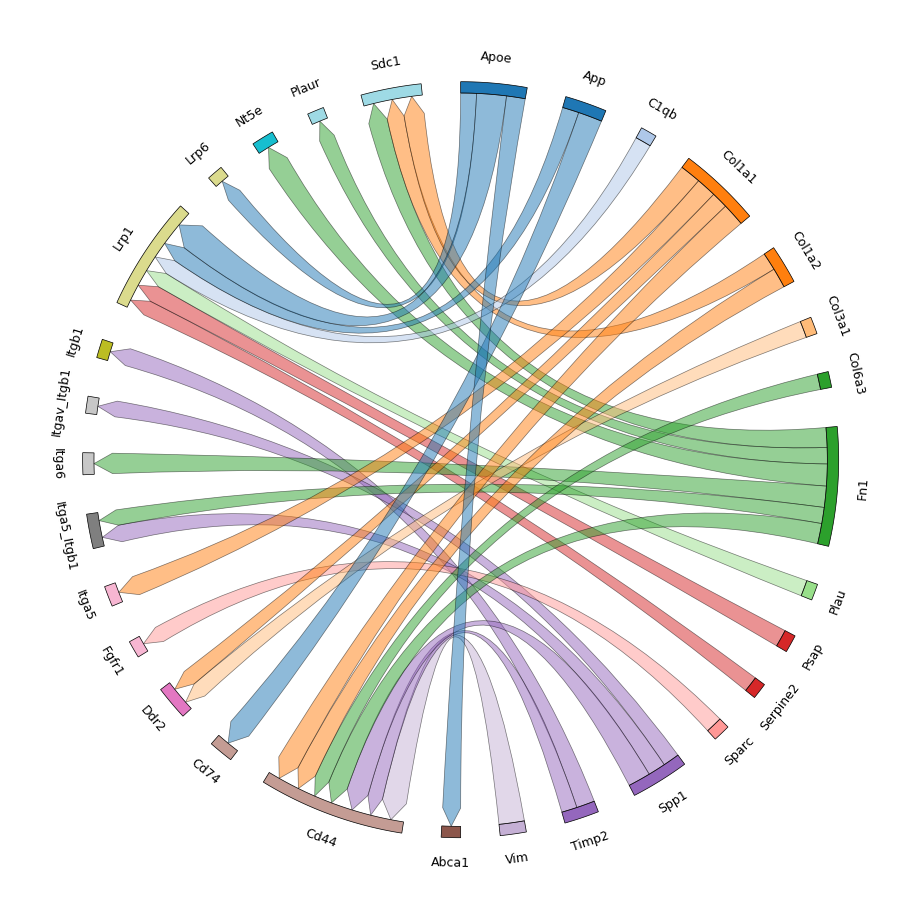

Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/chord_diagram_demo/chord_liana_geom_mean_top30_ALL.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/chord_diagram_demo/chord_liana_geom_mean_top30_ALL.pdf


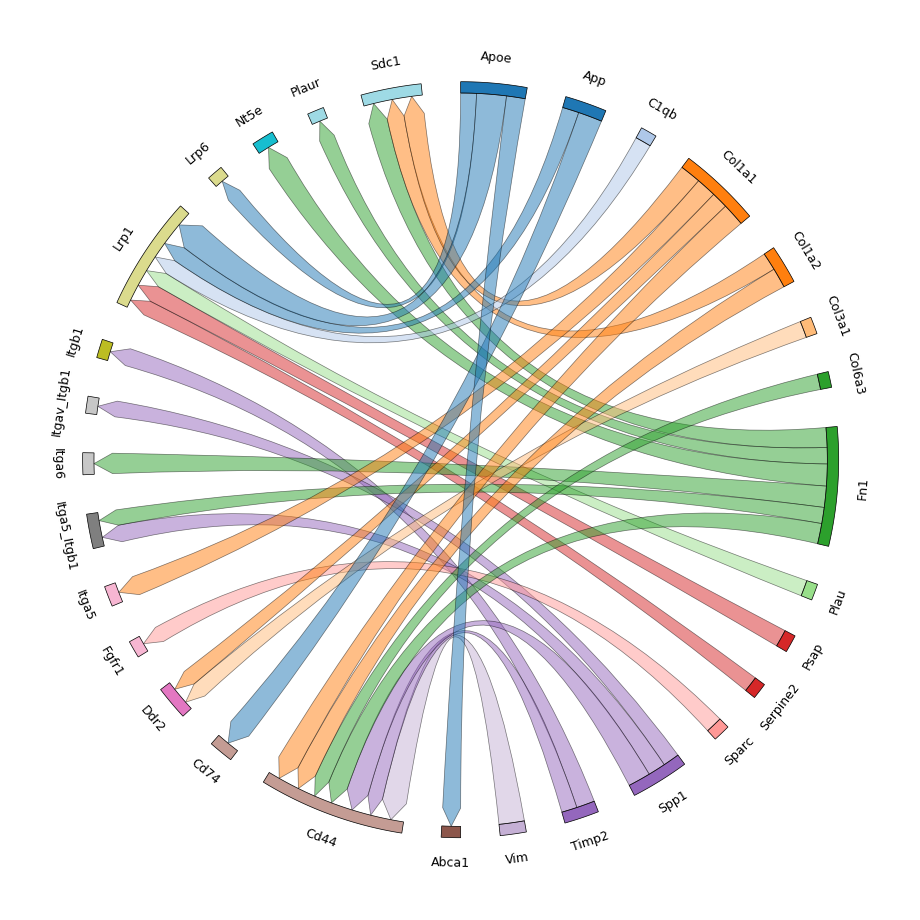

In [4]:
# You can change cmap (e.g., "tab20", "Set3") and link aesthetics below
circos_lr = Circos.chord_diagram(
    mat,
    space=6,                                   # sector gap
    cmap="tab20",                              # sector colors
    label_kws=dict(size=9),                    # label text size
    link_kws=dict(ec="black", lw=0.5, direction=1),  # link styling
)

# (optional) enlarge figure and adjust margins
fig = circos_lr.plotfig()
fig.set_size_inches(11.5, 8.5)                 # letter-ish size
# Default layout is okay for quick export; you can fine-tune with circos_lr.ax.set_position if needed.

# Save PNG & PDF
tag = (SELECT_COND or "ALL")
base = OUT_DIR / f"chord_liana_{METRIC}_top{TOP_N}_{tag}"
fig.savefig(base.with_suffix(".png"), dpi=300)
fig.savefig(base.with_suffix(".pdf"), dpi=300)

display(fig)
print("Saved:", base.with_suffix(".png"))
print("Saved:", base.with_suffix(".pdf"))


In [8]:
# --- Link color encodes Moran's I; link width encodes "score" (e.g., geom_mean) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from pycirclize import Circos

# Expect `top` to have: ligand, receptor, score, morans (from Cell 3)
assert {"ligand","receptor","score","morans"}.issubset(top.columns)

# 1) Build sector list (ligands on left half, receptors on right half)
ligands   = top["ligand"].astype(str).unique().tolist()
receptors = top["receptor"].astype(str).unique().tolist()

# Optional: prefix to avoid name collisions across sets
L_prefix = "L:"
R_prefix = "R:"
L_secs = [f"{L_prefix}{g}" for g in ligands]
R_secs = [f"{R_prefix}{g}" for g in receptors]
sectors = L_secs + R_secs

# 2) Set up Circos with equal sector sizes; add an outer track for labels
sector2range = {sec: (0.0, 1.0) for sec in (L_secs + R_secs)}  # dict mapping: sector -> (start,end)
circos = Circos(sector2range, space=6)


# track = circos.add_track((90, 100))        # outer ring from radius 90->100
for sec in circos.sectors:
    # Sector labels: strip prefix for readability
    label = sec.name[len(L_prefix):] if sec.name.startswith(L_prefix) else sec.name[len(R_prefix):]
    track.axis(sec.name)
    track.text(label, size=9, r=100.5, va="center", ha="center", rotation="auto")

# 3) Distribute links along each sector arc so they don't all stack
#    We allocate a unique sub-interval (0..1) per link for each sector.
from collections import Counter, defaultdict

counts_L = Counter(f"{L_prefix}{l}" for l in top["ligand"].astype(str))
counts_R = Counter(f"{R_prefix}{r}" for r in top["receptor"].astype(str))

# current slot index for each sector
next_idx = defaultdict(int)

def alloc_interval(name, counts_dict, next_idx_dict):
    total = counts_dict[name]
    i = next_idx_dict[name]
    # equally spaced non-overlapping slice in [0,1]
    start = i / total
    end   = (i + 1) / total
    next_idx_dict[name] += 1
    return (start, end)

# 4) Color map for Moran’s I: diverging, symmetric around 0
mor_vals = top["morans"].to_numpy()
if mor_vals.size == 0:
    raise ValueError("No Moran's I values found.")
vmax = float(np.nanmax(np.abs(mor_vals)))
vmax = vmax if vmax > 0 else 1e-6          # guard against all zeros
norm = colors.Normalize(vmin=-vmax, vmax=+vmax)
cmap = cm.get_cmap("RdBu_r")               # blue = negative, red = positive by default

# 5) Map "score" to line width
score_vals = top["score"].to_numpy()
smin, smax = float(np.nanmin(score_vals)), float(np.nanmax(score_vals))
def width_fn(s, smin=smin, smax=smax, wmin=0.6, wmax=5.5):
    if smax <= smin:  # guard
        return (wmin + wmax) / 2.0
    t = (s - smin) / (smax - smin)
    return float(wmin + t * (wmax - wmin))

# 6) Draw links
for _, row in top.iterrows():
    lig = f"{L_prefix}{row['ligand']}"
    rec = f"{R_prefix}{row['receptor']}"

    # allocate distinct sub-intervals for this link on each sector
    ivL = alloc_interval(lig, counts_L, next_idx)
    ivR = alloc_interval(rec, counts_R, next_idx)

    color = cmap(norm(float(row["morans"])))
    lw    = width_fn(float(row["score"]))

    # ec = edgecolor (line color); alpha slightly <1 for overlap
    circos.link((lig, ivL[0], ivL[1]), (rec, ivR[0], ivR[1]),
            color=color, alpha=0.9, height_ratio=0.5,
            lw=lw, zorder=10 + 1000 * norm(float(row["morans"])))

# 7) Figure, title, colorbar, save
fig = circos.plotfig()
fig.set_size_inches(11.5, 8.5)

# Position tweak (optional): [left, bottom, width, height]
circos.ax.set_position([0.05, 0.15, 0.90, 0.80])

# Title
tag = (SELECT_COND or "ALL")
title = f"LIANA chord diagram  ·  metric={METRIC} (width)  ·  Moran's I (color)  ·  top{TOP_N}  ·  {tag}"
fig.suptitle(title, fontsize=12, y=0.98)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([0.20, 0.06, 0.60, 0.030])     # centered horizontal bar
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Moran's I (link color)", fontsize=10)

# Save PNG/PDF
base = OUT_DIR / f"chord_liana_{METRIC}_top{TOP_N}_{tag}_moransColor"
fig.savefig(base.with_suffix(".png"), dpi=300)
fig.savefig(base.with_suffix(".pdf"), dpi=300)

display(fig)
print("Saved:", base.with_suffix(".png"))
print("Saved:", base.with_suffix(".pdf"))
print(f"Color scale symmetric: vmin={-vmax:.3g}, vmax={vmax:.3g}  |  width range ≈ [{width_fn(smin):.2f}, {width_fn(smax)::.2f}]")


NameError: name 'track' is not defined

/tmp/ipykernel_9331/4089702446.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(CMAP_NAME)
/tmp/ipykernel_9331/4089702446.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(base.with_suffix(".png"), dpi=300)
/tmp/ipykernel_9331/4089702446.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(base.with_suffix(".pdf"), dpi=300)
/home/jon/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


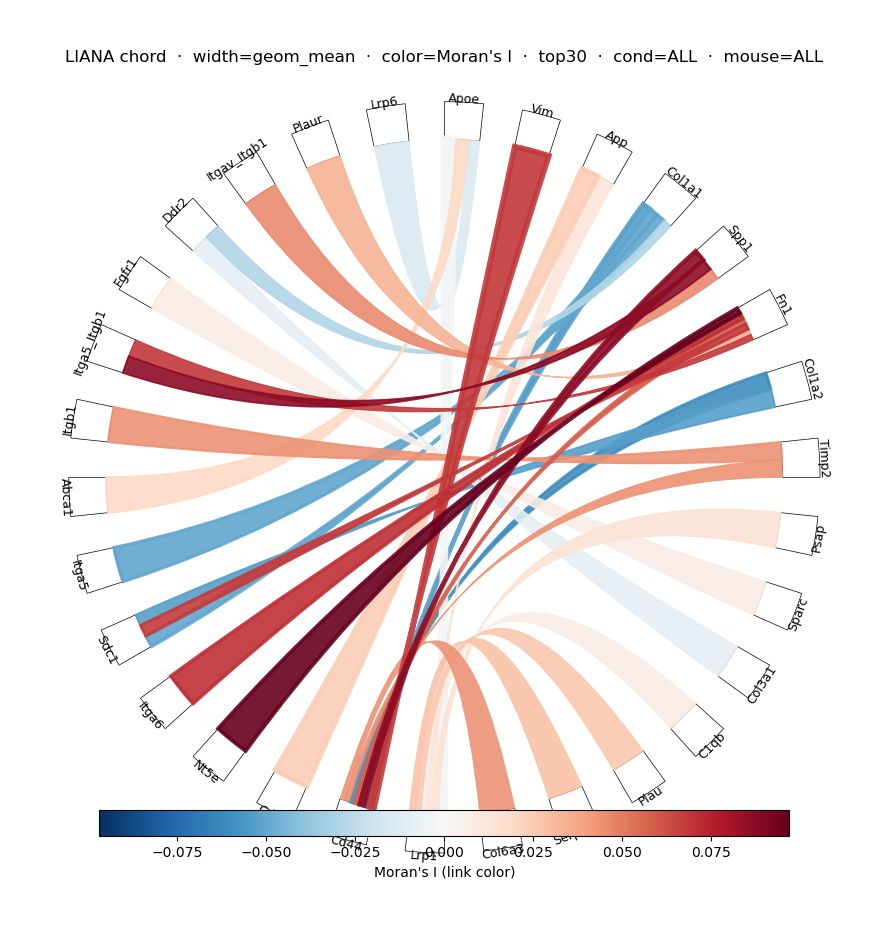

Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/chord_diagram_demo/chord_liana_geom_mean_top30_cond-ALL_mouse-ALL_moransColor.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/chord_diagram_demo/chord_liana_geom_mean_top30_cond-ALL_mouse-ALL_moransColor.pdf
Color scale symmetric at ±0.0969; width range ≈ [0.60, 5.50]


/home/jon/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)


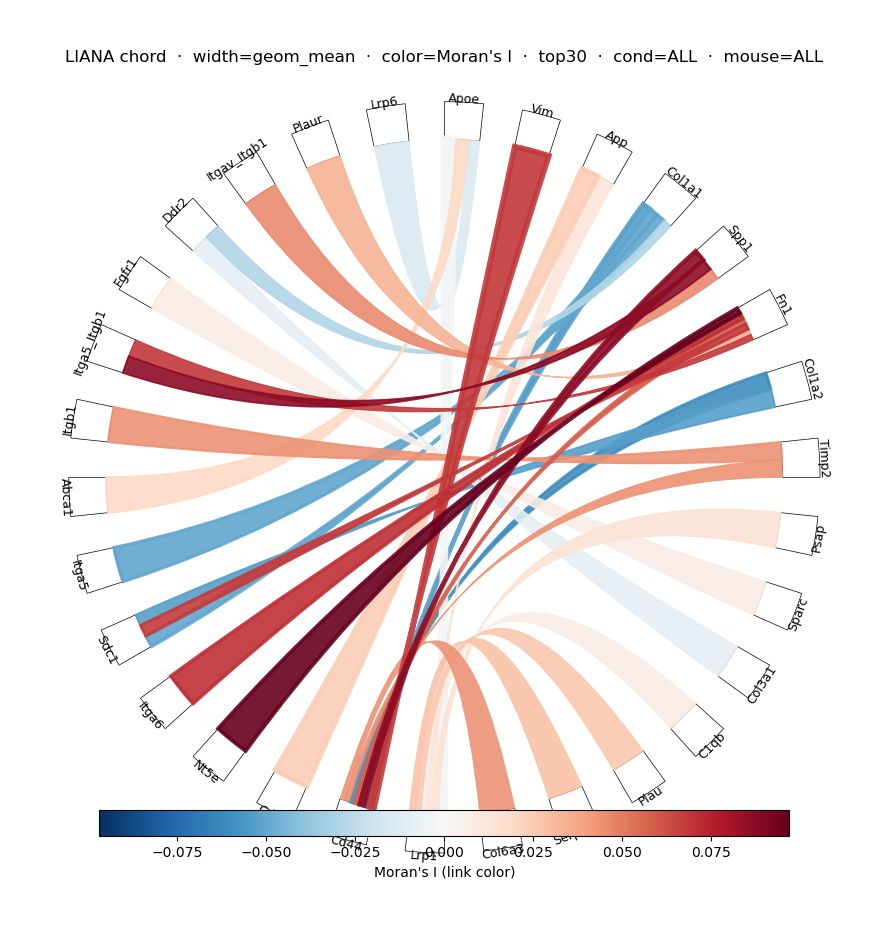

In [9]:
# --- Chord diagram with Moran's I as link color & width by score ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from pycirclize import Circos
from collections import Counter, defaultdict

# ========== CONFIG ==========
CSV_IN   = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/master_df_interactions_all.csv")

# Optional filters (set to None to pool everything)
SELECT_COND  = None           # e.g., "RT", "Cy", "PSCA", etc., or None
SELECT_MOUSE = None           # e.g., "RTCyPSCA_2_4", or None

# What defines "interaction strength" (for link width)
#   "geom_mean" -> sqrt(ligand_means * receptor_means)
#   "morans"    -> |Moran's I| (if you want width by spatial autocorr)
#   "ligand_means" or "receptor_means"
METRIC = "geom_mean"

TOP_N  = 30                   # number of strongest interactions to plot
SPACE  = 6                    # sector gap (degrees)
SECTOR_LABEL_SIZE = 9
WMIN, WMAX = 0.6, 5.5         # min/max link line width
CMAP_NAME = "RdBu_r"          # diverging; red=positive, blue=negative (flip with "RdBu")

OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Circos")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ============================

# 1) Load and subset
df = pd.read_csv(CSV_IN, sep=None, engine="python")

required_cols = {"ligand","receptor","ligand_means","receptor_means","morans"}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

sub = df.copy()
if "condition" in sub.columns and SELECT_COND is not None:
    sub = sub.query("condition == @SELECT_COND").copy()
if "mouse" in sub.columns and SELECT_MOUSE is not None:
    sub = sub.query("mouse == @SELECT_MOUSE").copy()

# Coerce numerics & drop NAs
for c in ["ligand_means","receptor_means","morans"]:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")
sub = sub.dropna(subset=["ligand","receptor","ligand_means","receptor_means","morans"])

# Aggregate duplicates (if any) across replicates by mean
grp = sub.groupby(["ligand","receptor"], as_index=False).agg(
    ligand_means=("ligand_means","mean"),
    receptor_means=("receptor_means","mean"),
    morans=("morans","mean"),
)

# 2) Scoring for ranking (controls link width)
if METRIC == "geom_mean":
    score = np.sqrt(grp["ligand_means"].clip(lower=0) * grp["receptor_means"].clip(lower=0))
elif METRIC == "morans":
    score = grp["morans"].abs()
elif METRIC == "ligand_means":
    score = grp["ligand_means"].clip(lower=0)
elif METRIC == "receptor_means":
    score = grp["receptor_means"].clip(lower=0)
else:
    raise ValueError("Unknown METRIC. Choose from: geom_mean, morans, ligand_means, receptor_means")

top = grp.assign(score=score).sort_values("score", ascending=False).head(TOP_N)
assert not top.empty, "No interactions selected — relax filters or lower TOP_N."

# 3) Define sectors: ligands on left, receptors on right (names prefixed to avoid collisions)
ligands   = top["ligand"].astype(str).unique().tolist()
receptors = top["receptor"].astype(str).unique().tolist()
L_prefix, R_prefix = "L:", "R:"
L_secs = [f"{L_prefix}{g}" for g in ligands]
R_secs = [f"{R_prefix}{g}" for g in receptors]

# pycirclize (version-dependent) constructor expects a dict: sector -> (start,end)
sector2range = {sec: (0.0, 1.0) for sec in (L_secs + R_secs)}
circos = Circos(sector2range, space=SPACE)

# 4) Draw an outer track + labels per sector
for sec in circos.sectors:
    track = sec.add_track((90, 100))           # radial ring [inner, outer]
    track.axis()                               # tick ring; keep simple
    label = sec.name[len(L_prefix):] if sec.name.startswith(L_prefix) else sec.name[len(R_prefix):]
    track.text(label, size=SECTOR_LABEL_SIZE, r=101, adjust_rotation=True, orientation="horizontal")

# 5) Allocate non-overlapping sub-intervals within each sector arc for each link
counts_L = Counter(f"{L_prefix}{l}" for l in top["ligand"].astype(str))
counts_R = Counter(f"{R_prefix}{r}" for r in top["receptor"].astype(str))
next_idx = defaultdict(int)

def alloc_interval(name, counts_dict, next_idx_dict):
    total = counts_dict[name]
    i = next_idx_dict[name]
    start = i / total
    end   = (i + 1) / total
    next_idx_dict[name] += 1
    return (start, end)

# 6) Color map for Moran’s I (diverging, symmetric around 0)
mor_vals = top["morans"].to_numpy()
vmax = float(np.nanmax(np.abs(mor_vals)))
vmax = vmax if vmax > 0 else 1e-6
norm = colors.Normalize(vmin=-vmax, vmax=+vmax)
cmap = cm.get_cmap(CMAP_NAME)

# 7) Width mapping for score
score_vals = top["score"].to_numpy()
smin, smax = float(np.nanmin(score_vals)), float(np.nanmax(score_vals))
def width_fn(s, smin=smin, smax=smax, wmin=WMIN, wmax=WMAX):
    if smax <= smin:
        return (wmin + wmax) / 2.0
    t = (s - smin) / (smax - smin)
    return float(wmin + t * (wmax - wmin))

# 8) Draw links
for _, row in top.iterrows():
    lig = f"{L_prefix}{row['ligand']}"
    rec = f"{R_prefix}{row['receptor']}"

    ivL = alloc_interval(lig, counts_L, next_idx)
    ivR = alloc_interval(rec, counts_R, next_idx)

    color = cmap(norm(float(row["morans"])))
    lw    = width_fn(float(row["score"]))

    # pycirclize v0.5+ link signature: ((name,start,end), (name,start,end), **kwargs)
    circos.link((lig, ivL[0], ivL[1]),
                (rec, ivR[0], ivR[1]),
                color=color, alpha=0.9, lw=lw,
                height_ratio=0.5,  # arc height (0..1)
                zorder=10 + 1000 * norm(float(row["morans"])) )

# 9) Figure, colorbar, save
fig = circos.plotfig()
fig.set_size_inches(11.5, 8.5)
circos.ax.set_position([0.05, 0.15, 0.90, 0.80])  # [left, bottom, width, height]

tag_cond  = (SELECT_COND  or "ALL")
tag_mouse = (SELECT_MOUSE or "ALL")
title = f"LIANA chord  ·  width={METRIC}  ·  color=Moran's I  ·  top{TOP_N}  ·  cond={tag_cond}  ·  mouse={tag_mouse}"
fig.suptitle(title, fontsize=12, y=0.985)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cax = fig.add_axes([0.20, 0.06, 0.60, 0.030])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Moran's I (link color)", fontsize=10)

# Save
base = OUT_DIR / f"chord_liana_{METRIC}_top{TOP_N}_cond-{tag_cond}_mouse-{tag_mouse}_moransColor"
fig.savefig(base.with_suffix(".png"), dpi=300)
fig.savefig(base.with_suffix(".pdf"), dpi=300)

display(fig)
print(f"Saved: {base.with_suffix('.png')}")
print(f"Saved: {base.with_suffix('.pdf')}")
print(f"Color scale symmetric at ±{vmax:.3g}; width range ≈ [{width_fn(smin):.2f}, {width_fn(smax):.2f}]")
